# First-order syntax testing - the randomization test

The most common test for first-order syntax was introduced in:

Lehmann, D., Faber, P. L., Galderisi, S., Herrmann, W. M., Kinoshita, T., Koukkou,
M., Mucci, A., Pascual-Marqui, R. D., Saito, N., Wackermann, J., Winterer, G., &
Koenig, T. (2005). EEG microstate duration and syntax in acute, medication-naive,
first-episode schizophrenia: a multi-center study. *Psychiatry Research:
Neuroimaging*, 138(2), 141-156.

The key argument is _“If transitions from a preceding state into a next state occurred randomly, i.e., independent of the class of the preceding state, observed transition values would be proportional to the relative occurrence of the microstate classes. Under this null hypothesis, the expected probability of transition from state i to state j is”_
$$
P^{*}_{ij} = \frac{p_i \, p_j}{1 - p_i}, \qquad i \neq j,
$$
This is the **null hypothesis in joint probability form**, the numerator expressing the probability that we find state $i$ at time $t$ **and** state $j$ at time $t+1$.

**Null hypothesis (conditional form).** As per the relation between joint and conditional probability, the conditional probability form is:
$$
T^{*}_{ij} = \frac{p_j}{1 - p_i}, \qquad i \neq j.
$$

The empirical (observed) counterparts $P_{ij}$ and $T_{ij}$ are obtained in
mstsa from `mstsa.tpm_joint` and `mstsa.tpm_cond`. The null/expected joint
matrix $P^{*}$ is obtained from `mstsa.tpm_joint_exp` -- **not** `tpm_joint`,
which computes the *observed* matrix. There is no dedicated function for the
conditional null $T^{*}$; it is built directly from the formula above
(as done throughout this notebook).

**Note:** The test is applied to microstate **_jump_** sequences (aka embedded 
sequence), i.e. after removing duplicate labels. Thus $P^{*}$ and $T^{*}$ refer to 
jump sequences.


**The $\chi^2$ part:**  
The chi-squared-type statistic

$$t = \sum_{i \neq j} \frac{(P_{ij} - P_{ij}^{*})^2}{P_{ij}^{*}}$$

is computed on the group-averaged matrices and tested against a permutation null 
distribution.

`mstsa.transition_syntax_test(file_list, K, n_perm)` implements this procedure 
and returns the test statistic $t$ and the 95th-percentile threshold $t_{\text{thr}}$.

## Using the randomization test

**Data**: MPILMBB EEG microstate sequences

**Procedure:**
1. Compute the group-level empirical jump-sequence transition matrix $T$.
2. Compute the null (hypothesis) matrix $T^{*}$ from the group-level marginal $p_i$.
3. Use `mstsa.transition_syntax_test` to compare the empirical $P$ to $P^{*}$ (joint form) via a permutation-based chi-squared statistic, plus a per-cell significance test (each cell's observed vs. expected count under $T^{*}$, standardized and converted to a two-sided $p$-value) to see *which* transitions drive the result.

In [1]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import mstsa

print(f"mstsa version: {mstsa.__version__}")

mstsa version: 0.4.3


In [2]:
data_path = "../data/mpilmbb"
fs = 250          # Hz (4 ms / sample)
smoothing = 'b3'  # smoothing level
K = 4             # single clustering solution, no cross-K comparison

pattern = f"{data_path}/*_EC_ms_{smoothing}_K{K}_ep00.npy"
subjects = sorted(re.match(r'(sub-\d+)_', os.path.basename(f)).group(1)
                   for f in glob.glob(pattern))
print(f"{len(subjects)} subjects with EC, smoothing={smoothing!r}, K={K}")

201 subjects with EC, smoothing='b3', K=4


In [3]:
file_list = [f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy" for subj in subjects]

t_stat, t_thr = mstsa.transition_syntax_test(file_list, K=K, n_perm=5000, verbose=False)
print(f"Test statistic: {t_stat:.2e}")
print(f"Chi2 threshold: {t_thr:.2e}")
print(f"Permutation test {'IS' if t_stat > t_thr else 'is NOT'} significant.")

Test statistic: 4.57e-03
Chi2 threshold: 1.87e-04
Permutation test IS significant.


In [4]:
from scipy.stats import norm

# pooled group-level jump-transition counts and marginal, across all subjects
counts = np.zeros((K, K))
jump_symbol_counts = np.zeros(K)
for subj in subjects:
    fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
    x = np.load(fname)
    jump_s, _ = mstsa.embedded_process(x)
    for a, b in zip(jump_s[:-1], jump_s[1:]):
        counts[a, b] += 1
    for s in jump_s:
        jump_symbol_counts[s] += 1

n_from = counts.sum(axis=1)
T_group = counts / n_from[:, None]              # group-level empirical T (conditional)
P_i_group = jump_symbol_counts / jump_symbol_counts.sum()

# randomization-test null matrix (Lehmann et al., 2005), conditional form, built directly from
# the group-level marginal: T*_ij = P_i[j] / (1 - P_i[i])
T_null_group = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        if i != j:
            T_null_group[i, j] = P_i_group[j] / (1 - P_i_group[i])

# per-cell significance: observed vs. expected counts under T_null_group,
# standardized and converted to a two-sided p-value
expected = n_from[:, None] * T_null_group
mask_offdiag = ~np.eye(K, dtype=bool)
z_cell = np.zeros((K, K))
p_cell = np.ones((K, K))
z_cell[mask_offdiag] = (counts[mask_offdiag] - expected[mask_offdiag]) / np.sqrt(expected[mask_offdiag])
p_cell[mask_offdiag] = 2 * (1 - norm.cdf(np.abs(z_cell[mask_offdiag])))

np.set_printoptions(precision=3, suppress=True)
print("T_group (pooled empirical, n=201 subjects):\n", T_group)
print("\nP_i_group (pooled jump marginal):", P_i_group)
print("\nT_null_group (randomization-test null):\n", T_null_group)
print(f"\nmax|T_group - T_null_group| = {np.abs(T_group - T_null_group)[mask_offdiag].max():.4f}")

T_group (pooled empirical, n=201 subjects):
 [[0.    0.284 0.356 0.361]
 [0.258 0.    0.353 0.389]
 [0.263 0.292 0.    0.445]
 [0.265 0.303 0.432 0.   ]]

P_i_group (pooled jump marginal): [0.208 0.227 0.278 0.287]

T_null_group (randomization-test null):
 [[0.    0.287 0.351 0.362]
 [0.269 0.    0.36  0.371]
 [0.288 0.315 0.    0.398]
 [0.292 0.318 0.39  0.   ]]

max|T_group - T_null_group| = 0.0473


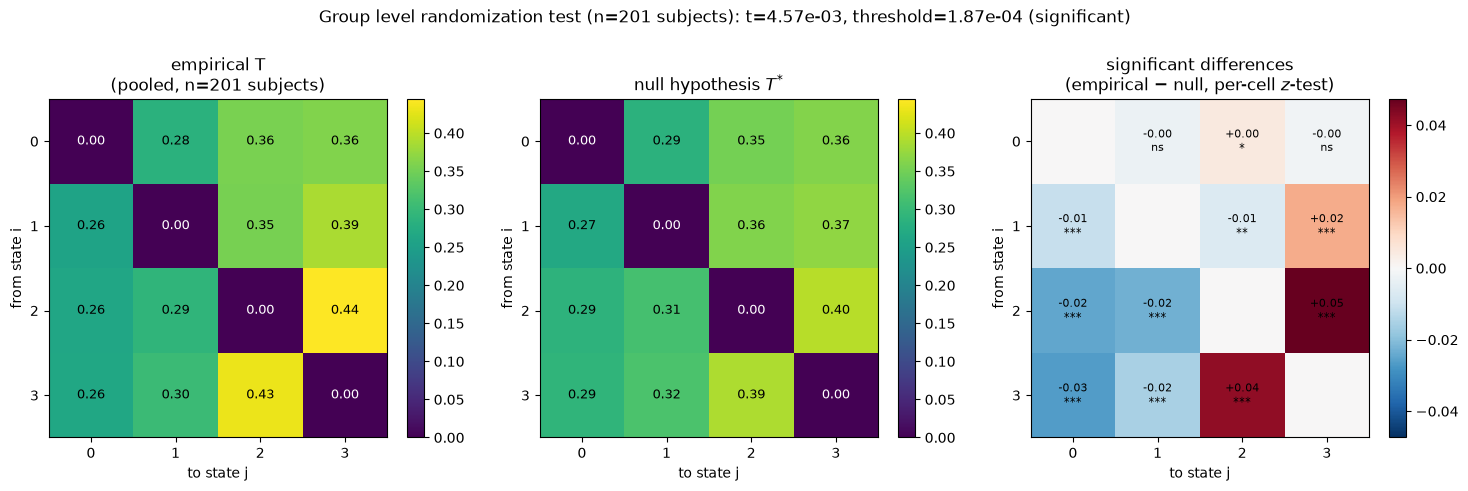

In [5]:
def plot_tpm(ax, T, title, vmax):
    im = ax.imshow(T, cmap='viridis', vmin=0, vmax=vmax)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f'{T[i, j]:.2f}', ha='center', va='center',
                    color='white' if T[i, j] < vmax / 2 else 'black', fontsize=9)
    ax.set_xticks(range(K))
    ax.set_yticks(range(K))
    ax.set_xlabel('to state j')
    ax.set_ylabel('from state i')
    ax.set_title(title)
    return im


def sig_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


vmax = max(T_group.max(), T_null_group.max())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im0 = plot_tpm(axes[0], T_group, f'empirical T\n(pooled, n={len(subjects)} subjects)', vmax)
im1 = plot_tpm(axes[1], T_null_group, 'null hypothesis $T^{*}$', vmax)

diff = T_group - T_null_group
im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
for i in range(K):
    for j in range(K):
        if i == j:
            continue
        label = f'{diff[i, j]:+.2f}\n{sig_stars(p_cell[i, j])}'
        axes[2].text(j, i, label, ha='center', va='center', fontsize=8)
axes[2].set_xticks(range(K))
axes[2].set_yticks(range(K))
axes[2].set_xlabel('to state j')
axes[2].set_ylabel('from state i')
axes[2].set_title('significant differences\n(empirical $-$ null, per-cell $z$-test)')

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)
fig.suptitle(f'Group level randomization test (n={len(subjects)} subjects): '
             f't={t_stat:.2e}, threshold={t_thr:.2e} '
             f'({"significant" if t_stat > t_thr else "not significant"})',
             y=1.04)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/01_syntax_test_lemon.png', dpi=150, bbox_inches='tight')
plt.show()

## Problems with the syntax test
1. In the null hypothesis, the next state is _not_ independent from the previous one. Independence would require $P_{ij}^{*} = p_i \, p_j$ but that wouldn't describe a jump process since the diagonal $p_i^2$ would be different from zero. 
2. It is impossible to model independence and the jump property at the same time.
3. The denominator in $T_{ij}^{*} = p_j / (1-p_i)$ shows that the $t \to t+1$ ($i \to j$) transition is not independent of $t$ ($i$)
4. An intuitive way of understanding the null hypothesis is by visualizing it as
    - I. Shuffle the sequence - now, $P_{ij} = p_i \, p_j$, but it's not a jump sequence
    - II. Remove the duplicates ($AA \to A$ etc.), thus rendering it a jump sequence. Now, $P_{ii} = 0$ but the rows of $T$ do not sum to $1.0$, making it an invalid transition matrix.
    - III. Re-scale the rows. This gives the known $P_{ij}^{*}$ and $T_{ij}^{*}$ with $1-p_i$ in the denominator.
5. **Note:** 
    - The duplicate removal changes the microstate distribution! 
    - Does this matter? 
    - Let's investigate...

In [6]:
# per-subject: jump marginal P_i, and the randomization-test null's OWN equilibrium
# distribution p_eq(T*) -- i.e. what the duplicate-removal + re-scaling
# construction actually converges to if iterated once, per subject
p_all = []
p_eq_null_all = []

for subj in subjects:
    fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
    x = np.load(fname)
    jump_s, _ = mstsa.embedded_process(x)
    P_i = mstsa.pmf(jump_s, K)

    T_null_i = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            if i != j:
                T_null_i[i, j] = P_i[j] / (1 - P_i[i])

    p_all.append(P_i)
    p_eq_null_all.append(mstsa.p_stationary(T_null_i))

p_all = np.array(p_all)              # (n_subjects, K)
p_eq_null_all = np.array(p_eq_null_all)
print(f"{len(subjects)} subjects: mean|p_eq(T*) - P_i| = "
      f"{np.abs(p_eq_null_all - p_all).mean():.4f}")

201 subjects: mean|p_eq(T*) - P_i| = 0.0129


In [7]:
from scipy.stats import wilcoxon


def stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


tests = []
for j in range(K):
    w_stat, w_p = wilcoxon(p_eq_null_all[:, j] - p_all[:, j])
    mean_diff = (p_eq_null_all[:, j] - p_all[:, j]).mean()
    tests.append(dict(state=j, wilcoxon_stat=w_stat, wilcoxon_p=w_p, mean_diff=mean_diff))
    print(f"state {j} (ms-{chr(65 + j)}): mean_diff={mean_diff:+.4f}  "
          f"Wilcoxon (paired): stat={w_stat:.1f} p={w_p:.3e} {stars(w_p)}")

state 0 (ms-A): mean_diff=+0.0121  Wilcoxon (paired): stat=1201.0 p=2.256e-27 ***
state 1 (ms-B): mean_diff=+0.0089  Wilcoxon (paired): stat=1755.0 p=2.761e-24 ***
state 2 (ms-C): mean_diff=-0.0085  Wilcoxon (paired): stat=3848.0 p=2.294e-14 ***
state 3 (ms-D): mean_diff=-0.0125  Wilcoxon (paired): stat=2161.0 p=3.811e-22 ***


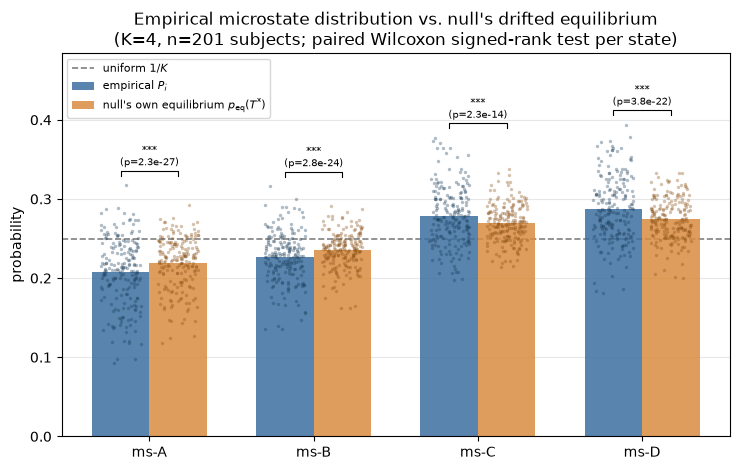

In [8]:
P_avg = p_all.mean(axis=0)
p_eq_null_avg = p_eq_null_all.mean(axis=0)
n_subj = p_all.shape[0]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
states = np.arange(K)
width = 0.35
x_emp = states - width / 2
x_null = states + width / 2

ax.bar(x_emp, P_avg, width, label=r"empirical $P_i$",
       color="#3b6fa0", alpha=0.85, zorder=2)
ax.bar(x_null, p_eq_null_avg, width, label=r"null's own equilibrium $p_{\mathrm{eq}}(T^{*})$",
       color="#d98c3f", alpha=0.85, zorder=2)

rng = np.random.default_rng(0)
jitter_emp = x_emp[None, :] + rng.uniform(-width / 2 * 0.7, width / 2 * 0.7, size=(n_subj, K))
jitter_null = x_null[None, :] + rng.uniform(-width / 2 * 0.7, width / 2 * 0.7, size=(n_subj, K))
ax.scatter(jitter_emp, p_all, s=6, color="#1c3d5a", alpha=0.35, zorder=3, linewidths=0)
ax.scatter(jitter_null, p_eq_null_all, s=6, color="#8a4f14", alpha=0.35, zorder=3, linewidths=0)

ax.axhline(1 / K, color="gray", ls="--", lw=1.2, zorder=1, label=r"uniform $1/K$")

y_top = max(p_all.max(), p_eq_null_all.max())
bar_top = np.maximum(p_all.max(axis=0), p_eq_null_all.max(axis=0))
for j, t in enumerate(tests):
    y = bar_top[j] + 0.012
    ax.plot([x_emp[j], x_emp[j], x_null[j], x_null[j]],
             [y, y + 0.006, y + 0.006, y], color="black", lw=0.8, zorder=4)
    ax.text(states[j], y + 0.009, f"{stars(t['wilcoxon_p'])}\n(p={t['wilcoxon_p']:.1e})",
            ha="center", va="bottom", fontsize=7, zorder=4)

ax.set_xticks(states)
ax.set_xticklabels([f"ms-{chr(65 + i)}" for i in range(K)])
ax.set_ylabel("probability")
ax.set_ylim(0, y_top + 0.09)
ax.set_title(f"Empirical microstate distribution vs. null's drifted equilibrium\n"
             f"(K={K}, n={n_subj} subjects; "
             f"paired Wilcoxon signed-rank test per state)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/01_empirical_vs_null_equilibrium.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
1. Frequent microstates are more likely to end up next to each other after shuffling. These will be reduced in the 'remove duplicates' step, thus lowering their probability in the null hypothesis.
2. The same effect is less likely for rarer microstates (lower $p_i$).
3. Due to conservation of probability, the null hypothesis has a **_systematically distorted_** microstate distribution $p$.


## A prediction about false positive 'specialized transitions'
- Since more frequent microstates, i.e. those with larger $p_i$, are under-represented in the null hypothesis, transitions between the two most frequent microstates will have a (_false !_) lower count in the null hypothesis
- **_Conclusion_: the most likely false positives are the transitions between the two most frequent microstate classes.**

## An alternative null hypothesis $T^{+}$: the most random transition matrix for fixed $p$

We will now construct the most random transition matrix $T^{+}$ for fixed $p$, i.e. it **does not** distort the microstate distribution $p$. The mathematical details of the construction will be given in a forthcoming paper. It can be proved that this matrix generates microstate sequences whose distribution is exactly $p$ and has the maximum attainable entropy rate.

We will show that the syntax test flags exactly those transitions as 'special' that we predicted above, the ones between the two most frequent microstates. Since the constructed process is as random as it gets, for fixed $p$, we can safely classify these results as false positives.

In [9]:
T_plus, info = mstsa.max_entropy_T(P_i_group)
print(f"T^+ converged in {info['n_iter']} iterations, marginal error {info['marginal_error']:.2e}")
print("\nT^+ (max-entropy, fixed p = P_i_group):\n", T_plus)
print("\ncheck P_i_group @ T^+ == P_i_group:", P_i_group @ T_plus)
print("                        P_i_group:", P_i_group)


T^+ converged in 17 iterations, marginal error 6.11e-15

T^+ (max-entropy, fixed p = P_i_group):
 [[0.    0.264 0.358 0.378]
 [0.242 0.    0.369 0.39 ]
 [0.268 0.301 0.    0.431]
 [0.274 0.308 0.418 0.   ]]

check P_i_group @ T^+ == P_i_group: [0.208 0.227 0.278 0.287]
                        P_i_group: [0.208 0.227 0.278 0.287]


In [10]:
import tempfile
import shutil

# Simulate one replicate sequence from T^+ per real subject, matched to that
# subject's real sequence length (a fair like-for-like comparison), and apply
# mstsa.transition_syntax_test to the simulated cohort -- T^+ has zero
# diagonal, so each simulated sequence is already a jump sequence.
tmp_dir = tempfile.mkdtemp(prefix="maxent_sim_")
sim_file_list = []
for idx, subj in enumerate(subjects):
    fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
    n_len = len(np.load(fname))
    x_sim = mstsa.mc_sample_path(T=T_plus, n=n_len)
    sim_fname = os.path.join(tmp_dir, f"sim_{idx:03d}.npy")
    np.save(sim_fname, x_sim)
    sim_file_list.append(sim_fname)

t_stat_plus, t_thr_plus = mstsa.transition_syntax_test(sim_file_list, K=K, n_perm=5000, verbose=False)
print(f"Test statistic: {t_stat_plus:.2e}")
print(f"Chi2 threshold: {t_thr_plus:.2e}")
print(f"Permutation test {'IS' if t_stat_plus > t_thr_plus else 'is NOT'} significant.")
print(f"\n-> even sequences simulated from the MAXIMALLY RANDOM T^+ (which preserves p exactly) "
      f"{'get flagged as non-random' if t_stat_plus > t_thr_plus else 'are correctly not flagged'}.")

Test statistic: 3.79e-03
Chi2 threshold: 7.31e-05
Permutation test IS significant.

-> even sequences simulated from the MAXIMALLY RANDOM T^+ (which preserves p exactly) get flagged as non-random.


In [11]:
# pool the simulated transition counts (same procedure as for the real
# cohort above), build the randomization-test null from the SIMULATED data's own
# marginal, and run the same per-cell significance test
counts_plus = np.zeros((K, K))
jump_symbol_counts_plus = np.zeros(K)
for sim_fname in sim_file_list:
    x_sim = np.load(sim_fname)
    for a, b in zip(x_sim[:-1], x_sim[1:]):
        counts_plus[a, b] += 1
    for s in x_sim:
        jump_symbol_counts_plus[s] += 1
shutil.rmtree(tmp_dir)  # done with the temp simulated sequences

n_from_plus = counts_plus.sum(axis=1)
T_plus_pooled = counts_plus / n_from_plus[:, None]
P_plus_pooled = jump_symbol_counts_plus / jump_symbol_counts_plus.sum()

T_null_plus = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        if i != j:
            T_null_plus[i, j] = P_plus_pooled[j] / (1 - P_plus_pooled[i])

expected_plus = n_from_plus[:, None] * T_null_plus
z_cell_plus = np.zeros((K, K))
p_cell_plus = np.ones((K, K))
z_cell_plus[mask_offdiag] = ((counts_plus[mask_offdiag] - expected_plus[mask_offdiag])
                              / np.sqrt(expected_plus[mask_offdiag]))
p_cell_plus[mask_offdiag] = 2 * (1 - norm.cdf(np.abs(z_cell_plus[mask_offdiag])))

print("T^+_pooled (empirical, simulated from T^+):\n", T_plus_pooled)
print("\nP_plus_pooled (simulated marginal, should match P_i_group):", P_plus_pooled)
print("\nT_null_plus (randomization-test null, from simulated marginal):\n", T_null_plus)
print("\nz-scores per cell (large |z| = strongly flagged as 'special'):\n", np.round(z_cell_plus, 1))

T^+_pooled (empirical, simulated from T^+):
 [[0.    0.264 0.358 0.378]
 [0.241 0.    0.369 0.39 ]
 [0.267 0.301 0.    0.432]
 [0.273 0.308 0.419 0.   ]]

P_plus_pooled (simulated marginal, should match P_i_group): [0.208 0.227 0.278 0.287]

T_null_plus (randomization-test null, from simulated marginal):
 [[0.    0.286 0.351 0.362]
 [0.269 0.    0.36  0.371]
 [0.288 0.315 0.    0.398]
 [0.291 0.318 0.39  0.   ]]

z-scores per cell (large |z| = strongly flagged as 'special'):
 [[  0.  -34.6   9.3  21.6]
 [-46.    0.   13.1  26.2]
 [-36.8 -23.3   0.   52. ]
 [-32.8 -18.7  45.3   0. ]]


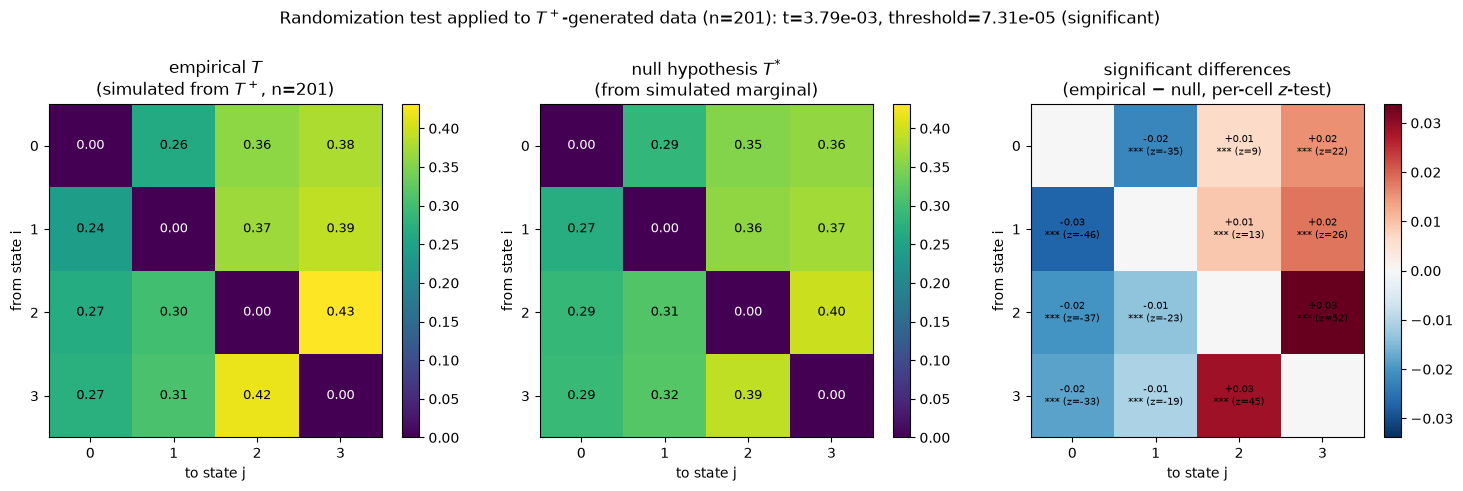


Largest |z| at cell (np.int64(2), np.int64(3)) (ms-C -> ms-D): z=52.0


In [12]:
vmax_plus = max(T_plus_pooled.max(), T_null_plus.max())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im0 = plot_tpm(axes[0], T_plus_pooled, f'empirical $T$\n(simulated from $T^+$, n={len(subjects)})', vmax_plus)
im1 = plot_tpm(axes[1], T_null_plus, 'null hypothesis $T^{*}$\n(from simulated marginal)', vmax_plus)

diff_plus = T_plus_pooled - T_null_plus
im2 = axes[2].imshow(diff_plus, cmap='RdBu_r', vmin=-np.abs(diff_plus).max(), vmax=np.abs(diff_plus).max())
for i in range(K):
    for j in range(K):
        if i == j:
            continue
        # at this sample size essentially every cell is "***" -- report the
        # z-score too, since its magnitude is what actually distinguishes
        # the predicted cells (largest |z| = C<->D, the two most frequent
        # microstates) from the rest
        label = f'{diff_plus[i, j]:+.2f}\n{sig_stars(p_cell_plus[i, j])} (z={z_cell_plus[i, j]:.0f})'
        axes[2].text(j, i, label, ha='center', va='center', fontsize=7.5)
axes[2].set_xticks(range(K))
axes[2].set_yticks(range(K))
axes[2].set_xlabel('to state j')
axes[2].set_ylabel('from state i')
axes[2].set_title('significant differences\n(empirical $-$ null, per-cell $z$-test)')

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)
fig.suptitle(f'Randomization test applied to $T^+$-generated data (n={len(subjects)}): '
             f't={t_stat_plus:.2e}, threshold={t_thr_plus:.2e} '
             f'({"significant" if t_stat_plus > t_thr_plus else "not significant"})',
             y=1.04)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/01_syntax_test_maxent.png', dpi=150, bbox_inches='tight')
plt.show()

top_cell = np.unravel_index(np.argmax(np.abs(z_cell_plus)), z_cell_plus.shape)
print(f"\nLargest |z| at cell {top_cell} (ms-{chr(65+top_cell[0])} -> ms-{chr(65+top_cell[1])}): "
      f"z={z_cell_plus[top_cell]:.1f}")

**Observations:** 
- The randomization test rejects the null hypothesis for data generated by $T^{+}$, 
the most random jump process with distribution $p$ possible
- For $n=201$ subjects, every cell reaches significance
- The *largest* deviation is the predicted $C \leftrightarrow D$ transition
- This confirms the prediction: what the classical test reports as
"specialized syntax" is rooted in the distortion of $p$

### All jump processes have autocorrelations - independence is impossible

As argued above, statistical independence requires $P_{ij} = p_i \, p_j$ but 
this cannot be a jump process, and establishing the 'no duplicates' jump rule re-introduces autocorrelations.  
This is visualized below, where we compute the autocorrelation curves for the empirical microstate transition matrix, the randomization test null hypothesis $T^{*}$ and 
the maximum-entropy-for-fixed-$p$ version $T^{+}$.

**Method:** We compute autocorrelations as time-lagged mutual information, or 'autoinformation' (AIF).

In [13]:
N_PATHS = 15
N_SAMPLES = 50_000
K_MAX = 15
lags = np.arange(1, K_MAX)  # skip lag 0 (= H(X), not decay information)

cache_dir = "../data/cache/first_order_syntax_aif"
cache_file = os.path.join(cache_dir, f"aif_three_way_{smoothing}_K{K}_n{N_PATHS}_s{N_SAMPLES}.npz")
os.makedirs(cache_dir, exist_ok=True)

matrices_aif = [T_group, T_null_group, T_plus]
titles_aif = ["empirical $T$\n(pooled, n={} subjects)".format(len(subjects)),
              "randomization test $T^{*}$\n(group level)",
              "entropy-max $T_p^{+}$\n(group level)"]

if os.path.exists(cache_file):
    d_cache = np.load(cache_file)
    aif_means = d_cache["means"]
    aif_cis = d_cache["cis"]
    print(f"loaded cached AIF results from {cache_file}")
else:
    def mean_aif_with_ci(T, K, n_paths=N_PATHS, n_samples=N_SAMPLES, kmax=K_MAX, seed=0):
        curves = np.array([mstsa.aif(mstsa.mc_sample_path(T=T, n=n_samples), K=K, kmax=kmax, base='e')
                            for _ in range(n_paths)])
        mean = curves.mean(axis=0)
        sem = curves.std(axis=0, ddof=1) / np.sqrt(n_paths)
        return mean, 1.96 * sem

    aif_means = np.zeros((len(matrices_aif), K_MAX))
    aif_cis = np.zeros((len(matrices_aif), K_MAX))
    for i, T in enumerate(matrices_aif):
        aif_means[i], aif_cis[i] = mean_aif_with_ci(T, K)
    np.savez(cache_file, means=aif_means, cis=aif_cis)
    print(f"saved AIF results to {cache_file}")


loaded cached AIF results from ../data/cache/first_order_syntax_aif/aif_three_way_b3_K4_n15_s50000.npz


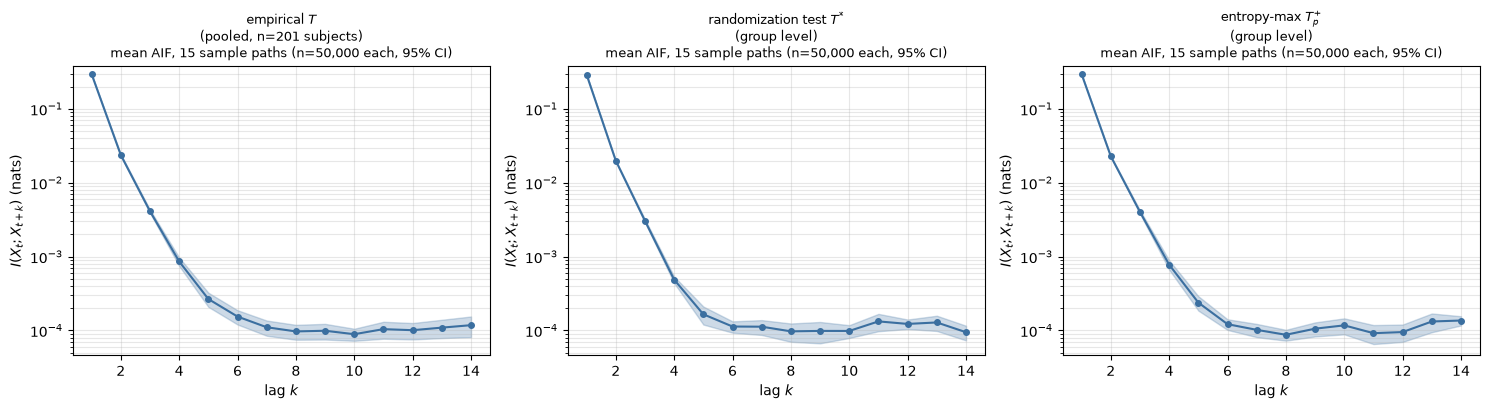

In [14]:
lo = min((aif_means[i, 1:] - aif_cis[i, 1:]).clip(min=1e-8).min() for i in range(len(matrices_aif)))
hi = max((aif_means[i, 1:] + aif_cis[i, 1:]).max() for i in range(len(matrices_aif)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, mean, ci95, title in zip(axes, aif_means, aif_cis, titles_aif):
    m, c = mean[1:], ci95[1:]
    ax.semilogy(lags, m, marker='o', ms=4, color='#3b6fa0')
    ax.fill_between(lags, np.maximum(m - c, 1e-8), m + c, color='#3b6fa0', alpha=0.25)
    ax.set_xlabel('lag $k$')
    ax.set_ylabel('$I(X_t;X_{t+k})$ (nats)')
    ax.set_title(f"{title}\nmean AIF, {N_PATHS} sample paths (n={N_SAMPLES:,} each, 95% CI)", fontsize=9)
    ax.set_ylim(lo * 0.7, hi * 1.3)
    ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/01_aif_three_way.png', dpi=150, bbox_inches='tight')
plt.show()


**Observations:**  
- All three transition matrices encode autocorrelations across many samples
- Jump processes cannot be decorrelated, i.e. stripped of all serial dependencies. At least exponentially decaying autocorrelations are an inherent property of the jump structure. 
- Demanding that the next state at $t+1$ _must be different_ from the previous one at $t$ **_is_** a serial dependence.
- More complicated time series memory can be present due to higher-order properties (as analyzed in `09_dementia_higher_order_syntax.ipynb`)
- The test removes any higher(-than-first)-order dependencies, but it distorts the lowest (=first) order
- An analogy: the problem is somewhat similar to estimating higher-order terms in a polynomial 
  $$
  u = a_1 x + a_2 x^2 + a_3 x^3 + \ldots
  $$
  but comparing it to a first-order polynomial $v = b x$. It should be compared to $v = a_1 x$, i.e. using the same first-order properties. Otherwise, any effective testing procedure will always find a difference between $u$ and $v$, independent of higher-order terms
- The $v= a_1 x$ condition is the first-order Markov surrogate of the microstate sequence, the one using the sequence's own empirical $p$ and $T$. This is one of the main messages in: von Wegner, F., Hermann, G., Tödt, I., Todtenhaupt, I. K., & Laufs, H. (2025). Higher-order EEG microstate syntax and surrogate testing. *Computers in Biology and Medicine*.

**An example using $T^{\ast}$:**  
- Assume a microstate distribution $p = \left[(0.1, 0.2, 0.4, 0.3 \right)$
- Build the randomization test matrix $T^{\ast} = p_j / (1-p_i)$ for $i \ne j$
- Assume microstate C at time $t$. The probability of D at $t+1$ is the fraction of D among A+B+D (rule: _anything but C_) is $0.3/(0.1+0.2+0.3) = 0.5$. If the microstate at $t$ was A, however, D would occur at $t+1$ with probability $0.3/(0.2+0.4+0.3) = 0.\bar{3}$ (rule: _anything but A_).
- Thus, the probability of state D at $t+1$ depends on the state at $t$, which depends on $t-1$ etc.; quantitatively, this results in the usual exponentially decaying correlations for Markov chains.

## The randomization test detects 'specialized transitions' in its own null hypothesis

The distortion of $p$ has another interesting side effect. The null hypothesis described by $T^{*}$ is constructed such that _“observed transition values would be proportional to the relative occurrence of the microstate classes”_.

- Microstate sequences constructed from $T^{*}$ should therefore not show specialized transitions, according to its own definition
- We will now show that the test indeed does detect specialized transitions in its own null. This effect is again explained in the distortion of $p$
- Overall, this will lead us to a theorem that tells us exactly what this iterative testing will converge to. (_Spoiler alert_: the uniform distribution)

In [15]:
from scipy.stats import chisquare


def randomization_null_from_p(p):
    # randomization-test null matrix, conditional form, built from a
    # marginal p via the package's own joint-form null: T*_ij = P*_ij / p_i
    P_star = mstsa.tpm_joint_exp(p)
    return P_star / np.asarray(p)[:, None]


N_LARGE = 50_000

cache_dir = "../data/cache/first_order_syntax_self_consistency"
cache_file = os.path.join(cache_dir, f"self_consistency_{smoothing}_K{K}_Nlarge{N_LARGE}.npz")
os.makedirs(cache_dir, exist_ok=True)

if os.path.exists(cache_file):
    d_cache = np.load(cache_file)
    n_real_arr = d_cache["n_real"]
    p_real_arr = d_cache["p_real"]
    p_large_arr = d_cache["p_large"]
    print(f"loaded cached self-consistency results from {cache_file}")
else:
    n_real_arr = np.zeros(len(subjects))
    p_real_arr = np.zeros(len(subjects))
    p_large_arr = np.zeros(len(subjects))

    for idx_s, subj in enumerate(subjects):
        fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
        x = np.load(fname)
        jump_s, _ = mstsa.embedded_process(x)
        P_subj = mstsa.pmf(jump_s, K)
        # this subject's OWN randomization-test null, built from their OWN marginal
        T_star_subj = randomization_null_from_p(P_subj)

        N_real = len(jump_s)
        n_real_arr[idx_s] = N_real

        def retest(n_samples):
            # T* has zero diagonal, so the simulated sequence is already a jump
            # sequence -- no embedding needed
            jump_sim = mstsa.mc_sample_path(T=T_star_subj, n=n_samples)
            P_sim = mstsa.pmf(jump_sim, K)
            # a fresh null built from the SIMULATED sequence's own marginal --
            # exactly what an analyst would compute, seeing only the simulated data
            T_star_sim = randomization_null_from_p(P_sim)
            counts = np.zeros((K, K))
            for a, b in zip(jump_sim[:-1], jump_sim[1:]):
                counts[a, b] += 1
            n_from = counts.sum(axis=1)
            expected = n_from[:, None] * T_star_sim
            mask = ~np.eye(K, dtype=bool)
            _, p_val = chisquare(counts[mask], expected[mask])
            return p_val

        p_real_arr[idx_s] = retest(N_real)
        p_large_arr[idx_s] = retest(N_LARGE)

    print("done.")
    np.savez(cache_file, n_real=n_real_arr, p_real=p_real_arr, p_large=p_large_arr)
    print(f"saved to {cache_file}")

n_subj = len(subjects)
flagged_real_05 = np.sum(p_real_arr < 0.05)
flagged_real_01 = np.sum(p_real_arr < 0.01)
flagged_large_05 = np.sum(p_large_arr < 0.05)
flagged_large_01 = np.sum(p_large_arr < 0.01)

print("\nSelf-consistency of T*: for each subject, simulate a sequence from "
      "their OWN T*, then re-test it against a fresh null built from the "
      "SIMULATED sequence's own marginal.\n")
print(f"At each subject's real sequence length (mean n={n_real_arr.mean():.0f}):")
print(f"  flagged @alpha=0.05: {flagged_real_05}/{n_subj} ({100 * flagged_real_05 / n_subj:.1f}%)")
print(f"  flagged @alpha=0.01: {flagged_real_01}/{n_subj} ({100 * flagged_real_01 / n_subj:.1f}%)")
print(f"\nAt fixed large sample size (n={N_LARGE:,}):")
print(f"  flagged @alpha=0.05: {flagged_large_05}/{n_subj} ({100 * flagged_large_05 / n_subj:.1f}%)")
print(f"  flagged @alpha=0.01: {flagged_large_01}/{n_subj} ({100 * flagged_large_01 / n_subj:.1f}%)")


loaded cached self-consistency results from ../data/cache/first_order_syntax_self_consistency/self_consistency_b3_K4_Nlarge50000.npz

Self-consistency of T*: for each subject, simulate a sequence from their OWN T*, then re-test it against a fresh null built from the SIMULATED sequence's own marginal.

At each subject's real sequence length (mean n=1647):
  flagged @alpha=0.05: 26/201 (12.9%)
  flagged @alpha=0.01: 11/201 (5.5%)

At fixed large sample size (n=50,000):
  flagged @alpha=0.05: 193/201 (96.0%)
  flagged @alpha=0.01: 192/201 (95.5%)


**Result:** 
- At each subject's real (short) sequence length, $T^{*}$-generated data is already flagged as having 'specialized transitions' by its own test in 12.9% of subjects at $\alpha=0.05$ (5.5% at $\alpha=0.01$), i.e. well above type I error tolerance
- Morevoer, it can be shown analytically that the null's microstate distribution is different from the input sequence. Thus, the test will **_always_** detect specialized syntax in its own null if enough samples are provided. At $n=50{,}000$, the rate rises to 96.0% ($\alpha=0.05$) and 95.5% ($\alpha=0.01$)
- Usually, data sampled from the null hypothesis should not be rejected by a statistical test but exactly this happens with the randomization test. In that sense, the null hypothesis is not self-consistent.

## If the null still has syntax, should we shuffle again?

It can be shown* that repeating this construction, $T^{*}$ from $p$, inevitably converges to a global fixed point defined by:
- the uniform distribution, i.e. all microstate probabilities will be $p_i = \frac{1}{K}$
- a 'uniform' jump transition matrix, i.e. $T_{ij} = \frac{1}{K-1}$
- the convergence rate can be computed analytically, and is a function of the number of microstate classes: 
$$
\lambda(K) = \frac{K-2}{K-1}.
$$
  This convergence is numerically verified below

*_(von Wegner, in preparation)_

## Convergence for K=4, 5, 6, across the full cohort

$\lambda(K)=(K-2)/(K-1)$ is a closed-form prediction for *every* cluster count,
not just $K=4$. We check it against real data for $K=4,5,6$ using all 201
subjects: for each subject and each $K$, the *longest* available epoch
(`ep00` only, smoothing `b3`, from `../data/mpilmbb`) is used to build
`T_jump` and from it `T_null`, which is then iterated. Each subject's
$\|p^{(n)}-1/K\|_\infty$ trajectory is normalized by its own $n=0$ value (subjects
start at different distances from uniform, but the *rate* is predicted to be the
same for all of them at fixed $K$) and averaged across the cohort, then compared
to the predicted geometric decay $\lambda(K)^n$.

In [16]:
from mstsa import p_stationary


def make_null_matrix_K(T, K):
    # same construction as make_null_matrix above, but with K passed explicitly
    # (make_null_matrix closes over the module-global K, fixed at 4 elsewhere
    # in this notebook, so it cannot be reused directly for K=5, 6)
    p_eq_T = p_stationary(T)
    T_p = np.tile(p_eq_T, [K, 1])
    T_pp = T_p - np.diag(np.diag(T_p))
    Ts = T_pp / T_pp.sum(axis=1, keepdims=True)
    p_eq_Ts = p_stationary(Ts)
    return Ts, p_eq_Ts


ext_data_path = "../data/mpilmbb"
n_iter_cohort = 20
K_values = [4, 5, 6]

cohort_results = {}  # K -> dict(lengths, p_linf_all, T_linf_all)
for K_ in K_values:
    pattern = f"{ext_data_path}/*_EC_ms_{smoothing}_K{K_}_ep*.npy"
    subj_files = {}
    for f in glob.glob(pattern):
        subj = re.match(r'(sub-\d+)_', os.path.basename(f)).group(1)
        subj_files.setdefault(subj, []).append(f)

    lengths, p_linf_all, T_linf_all = [], [], []
    off_diag_mask_ = ~np.eye(K_, dtype=bool)
    for subj, flist in sorted(subj_files.items()):
        # longest available epoch for this subject
        seqs = {f: np.load(f) for f in flist}
        best_f = max(seqs, key=lambda f: len(seqs[f]))
        x = seqs[best_f]
        lengths.append(len(x))

        jump, _ = mstsa.embedded_process(x)
        T_jump_ = mstsa.tpm_cond(jump, K_)
        T_null_, _ = make_null_matrix_K(T_jump_, K_)
        T_iter_ = T_null_.copy()
        p_iter_ = p_stationary(T_null_)
        p_res = [np.abs(p_iter_ - 1 / K_).max()]
        T_res = [np.abs(T_iter_[off_diag_mask_] - 1 / (K_ - 1)).max()]
        for _ in range(n_iter_cohort):
            T_iter_, p_iter_ = make_null_matrix_K(T_iter_, K_)
            p_res.append(np.abs(p_iter_ - 1 / K_).max())
            T_res.append(np.abs(T_iter_[off_diag_mask_] - 1 / (K_ - 1)).max())
        p_linf_all.append(np.array(p_res) / p_res[0])
        T_linf_all.append(np.array(T_res) / T_res[0])

    cohort_results[K_] = dict(
        lengths=np.array(lengths),
        p_linf_all=np.array(p_linf_all),
        T_linf_all=np.array(T_linf_all),
    )
    lengths_arr = cohort_results[K_]["lengths"]
    print(f"K={K_}: {len(subj_files)} subjects, longest-epoch sequence length "
          f"mean={lengths_arr.mean():.0f}  min={lengths_arr.min()}  max={lengths_arr.max()}")

K=4: 201 subjects, longest-epoch sequence length mean=16781  min=15469  max=32389


K=5: 201 subjects, longest-epoch sequence length mean=16782  min=15470  max=32389


K=6: 201 subjects, longest-epoch sequence length mean=16783  min=15489  max=32393


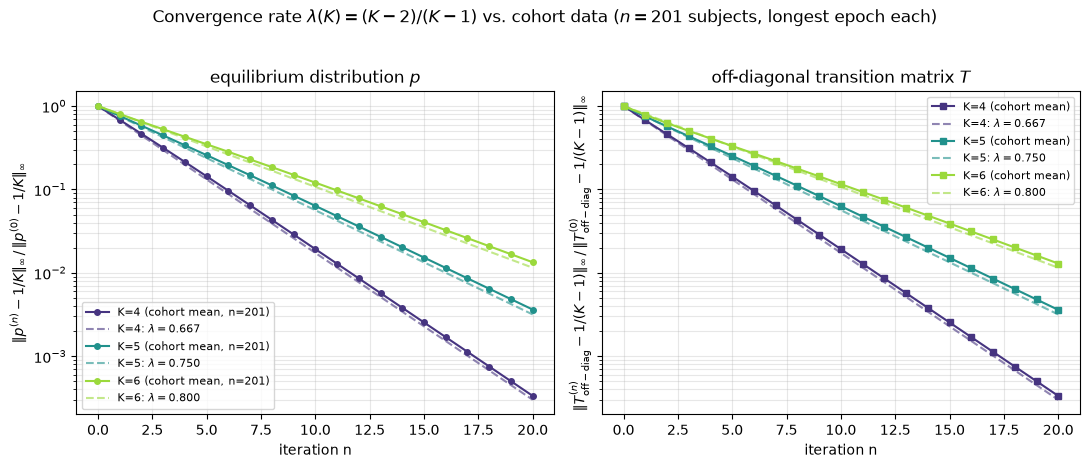

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(K_values)))
iters_cohort = np.arange(n_iter_cohort + 1)

for c, K_ in zip(colors, K_values):
    res = cohort_results[K_]
    lam = (K_ - 2) / (K_ - 1)
    p_mean = res["p_linf_all"].mean(axis=0)
    T_mean = res["T_linf_all"].mean(axis=0)

    axes[0].semilogy(iters_cohort, p_mean, marker='o', ms=4, color=c,
                      label=f'K={K_} (cohort mean, n={len(res["lengths"])})')
    axes[0].semilogy(iters_cohort, lam ** iters_cohort, ls='--', color=c, alpha=0.6,
                      label=rf'K={K_}: $\lambda={lam:.3f}$')

    axes[1].semilogy(iters_cohort, T_mean, marker='s', ms=4, color=c,
                      label=f'K={K_} (cohort mean)')
    axes[1].semilogy(iters_cohort, lam ** iters_cohort, ls='--', color=c, alpha=0.6,
                      label=rf'K={K_}: $\lambda={lam:.3f}$')

axes[0].set_xlabel('iteration n')
axes[0].set_ylabel(r'$\|p^{(n)}-1/K\|_\infty \,/\, \|p^{(0)}-1/K\|_\infty$')
axes[0].set_title('equilibrium distribution $p$')
axes[0].legend(fontsize=8)
axes[0].grid(True, which='both', alpha=0.3)

axes[1].set_xlabel('iteration n')
axes[1].set_ylabel(r'$\|T^{(n)}_{\mathrm{off-diag}}-1/(K-1)\|_\infty \,/\, \|T^{(0)}_{\mathrm{off-diag}}-1/(K-1)\|_\infty$')
axes[1].set_title('off-diagonal transition matrix $T$')
axes[1].legend(fontsize=8)
axes[1].grid(True, which='both', alpha=0.3)

fig.suptitle(r'Convergence rate $\lambda(K)=(K-2)/(K-1)$ vs. cohort data ($n=201$ subjects, longest epoch each)', y=1.03)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/01_convergence_rate_K4-5-6.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions
1. The randomization syntax test causes a slight but highly impactful distortion of the microstate distribution $p$
    - The distortion is not random but highly structured: more frequent microstates are reduced, rarer ones enhanced
    - This distortion biases the test towards detecting more than expected transitions between the most frequent microstates (and analogous reductions in rarer states)
2. The null hypothesis is not temporally independent and contains residual syntax. Thus, the randomization test detects 'specialized transitions' in its own null hypothesis.
3. Iterating the procedure leads away from the original microstate sequence and inevitably produces a uniform microstate distribution.
4. It is possible to prevent this distortion and to construct _'the most random microstate sequence with fixed $p$'_ - this is the matrix $T^{+}$ - but it is not clear whether comparing an empirical microstate sequence to this maximum-entropy version is neurobiologically meaningful.